# 📊 Relatório de Inteligência de Audiência: Tropa de Elite
**Pesquisa Primária e Análise de Sentimento (Março/2026)**

---

## 🎯 Objetivo Executivo
Este documento apresenta os resultados da pesquisa de mercado focada na aceitação, impacto psicológico e expectativas da audiência em relação à obra *Tropa de Elite*. 

Utilizamos uma arquitetura de dados relacional para cruzar o perfil dos espectadores com suas percepções morais e temáticas, visando entregar diretrizes claras para o marketing de relançamento ou desenvolvimento de uma sequência.

In [19]:
# Importação das bibliotecas visuais e de manipulação
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuração visual padrão (Estilo Corporate)
sns.set_theme(style="whitegrid", font_scale=1.1)

# 1. Extração e Carregamento (ETL) com encoding para ler acentos
df_resp = pd.read_csv("respondentes.csv", sep=';', encoding='latin1')
df_id = pd.read_csv("indentificacaoFilme.csv", sep=';', encoding='latin1')
df_temas = pd.read_csv("temasAbordados.csv", sep=';', encoding='latin1')
df_seq = pd.read_csv("expectativa_filme2.csv", sep=';', encoding='latin1')
df_cap = pd.read_csv("capitaoNascimentoOpnioes.csv", sep=';', encoding='latin1')

# 2. Filtragem e Modelagem Relacional (Cruzamento via 'nome')
df_watched = df_resp[df_resp['Assistiu'] == 'Sim'].copy()

df_id_watched = pd.merge(df_watched[['nome']], df_id, on='nome', how='inner')
df_temas_watched = pd.merge(df_watched[['nome']], df_temas, on='nome', how='inner')
df_seq_watched = pd.merge(df_watched[['nome']], df_seq, on='nome', how='inner')
df_cap_watched = pd.merge(df_watched[['nome']], df_cap, on='nome', how='inner')

print(f"✅ Base de dados processada com sucesso. Analisando {len(df_watched)} espectadores válidos.")

✅ Base de dados processada com sucesso. Analisando 53 espectadores válidos.


## 1. O Produto: Aceitação e Qualidade Percebida
A primeira etapa da nossa análise valida se a obra possui sustentação básica de mercado. Os dados confirmam que não temos um problema de qualidade de produto: a aprovação é quase unânime e as notas se concentram no topo da escala.

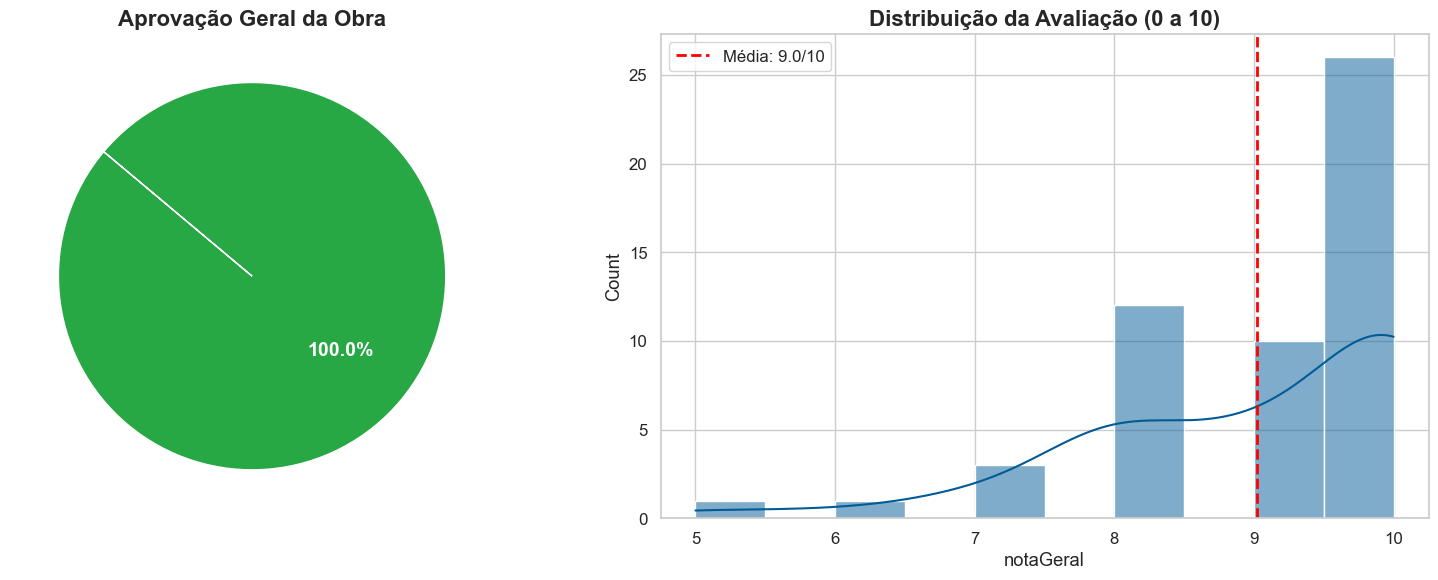

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Aprovação
gostou = df_watched['gostou'].value_counts()
axes[0].pie(gostou, labels=gostou.index, autopct='%1.1f%%', colors=['#28a745', '#dc3545'], startangle=140, textprops={'fontsize': 14, 'color': 'white', 'weight': 'bold'})
axes[0].set_title("Aprovação Geral da Obra", fontsize=16, fontweight='bold')

# Gráfico 2: Distribuição de Notas
media_nota = df_watched['notaGeral'].mean()
sns.histplot(df_watched['notaGeral'], bins=10, kde=True, color='#005b96', edgecolor='white', ax=axes[1])
axes[1].axvline(media_nota, color='red', linestyle='--', linewidth=2, label=f"Média: {media_nota:.1f}/10")
axes[1].set_title("Distribuição da Avaliação (0 a 10)", fontsize=16, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 2. O Gatilho do Sucesso: Realismo e Imersão
Descobrimos a "fórmula secreta" do engajamento desta obra. O espectador não se conecta majoritariamente com os personagens ou com o cenário, mas sim com os **conflitos**. Além disso, a análise de correlação prova que **quanto mais real a audiência acha o filme, maior é a nota que ela dá.**

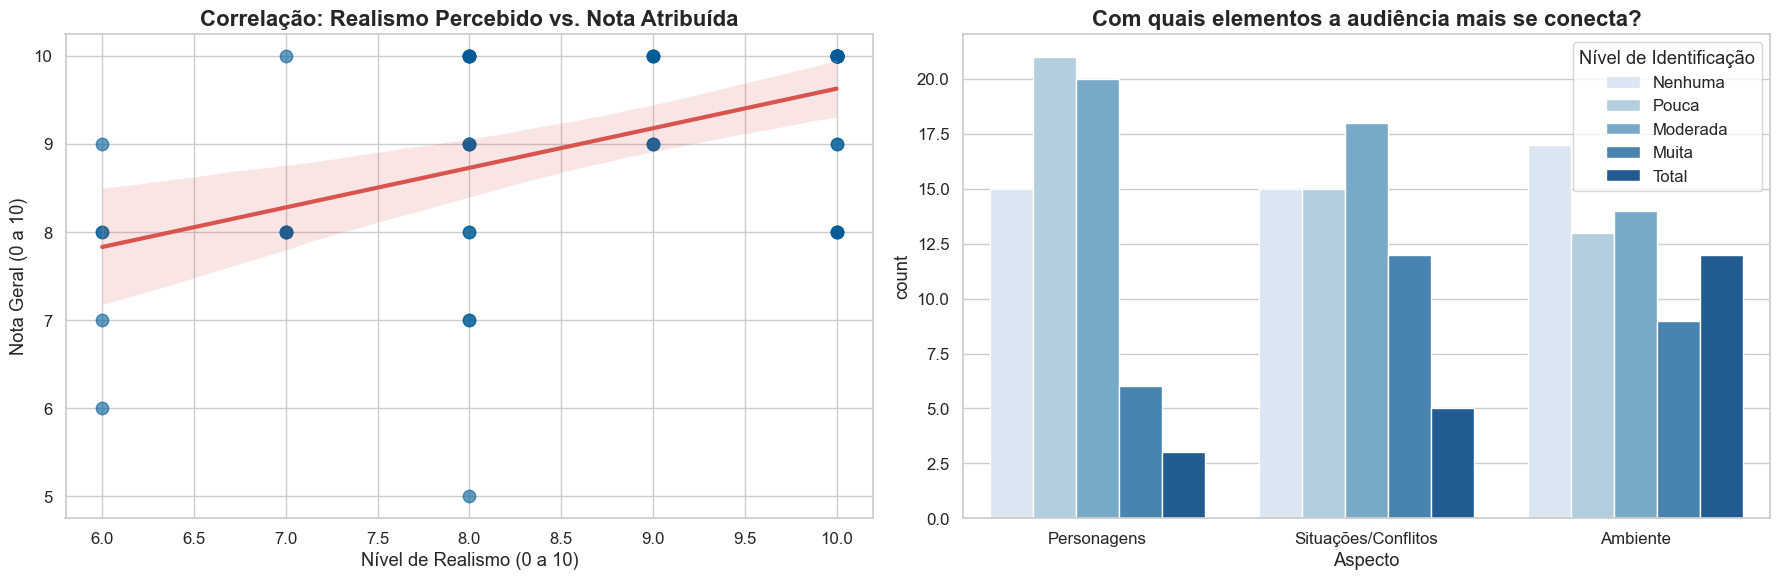

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Gráfico 3: Realismo vs Nota
sns.regplot(data=df_watched, x='nivelVeridico', y='notaGeral', scatter_kws={'alpha': 0.6, 's': 80, 'color': '#005b96'}, line_kws={'color': '#d9534f', 'linewidth': 3}, ax=axes[0])
axes[0].set_title("Correlação: Realismo Percebido vs. Nota Atribuída", fontsize=16, fontweight='bold')
axes[0].set_xlabel("Nível de Realismo (0 a 10)")
axes[0].set_ylabel("Nota Geral (0 a 10)")

# Gráfico 4: Imersão
df_id_melt = df_id_watched[['identificacaoPersonagem', 'identificacaoSituacao', 'identificacaoCenario']].melt(var_name='Aspecto', value_name='Nível')
df_id_melt['Aspecto'] = df_id_melt['Aspecto'].replace({'identificacaoPersonagem': 'Personagens', 'identificacaoSituacao': 'Situações/Conflitos', 'identificacaoCenario': 'Ambiente'})
ordem_niveis = ['Nenhuma', 'Pouca', 'Moderada', 'Muita', 'Total']

sns.countplot(data=df_id_melt, x='Aspecto', hue='Nível', hue_order=ordem_niveis, palette='Blues', ax=axes[1])
axes[1].set_title("Com quais elementos a audiência mais se conecta?", fontsize=16, fontweight='bold')
axes[1].legend(title='Nível de Identificação', loc='upper right')

plt.tight_layout()
plt.show()

## 3. Inteligência de Mercado: Temas e Demanda para Sequência
Para pautar campanhas publicitárias ou roteiros futuros, cruzamos o que mais chamou atenção no filme original com o que a audiência exige ver em uma continuação. Há uma forte demanda para focar na "Corrupção e Política", somado ao debate moral intenso sobre as ações do protagonista.

C:\Users\jggra\AppData\Local\Temp\ipykernel_12200\4043384103.py:4: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  top_temas = temas_sum.groupby(temas_sum.columns, axis=1).sum().sum().sort_values(ascending=False).head(4)
C:\Users\jggra\AppData\Local\Temp\ipykernel_12200\4043384103.py:8: FutureWarning: DataFrame.groupby with axis=1 is deprecated. Do `frame.T.groupby(...)` without axis instead.
  top_seq = seq_sum.groupby(seq_sum.columns, axis=1).sum().sum().sort_values(ascending=False)


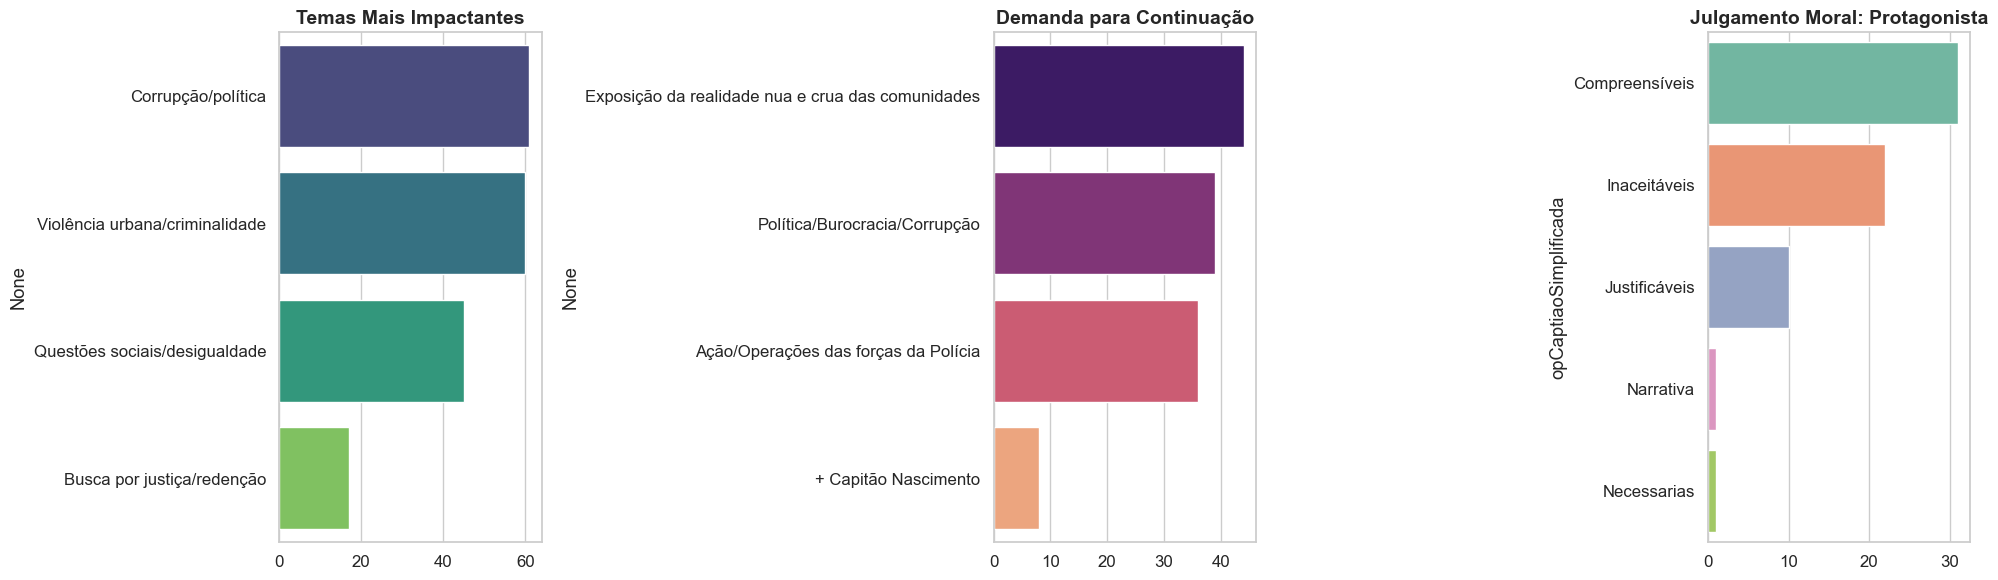

In [22]:
# Processamento rápido dos dados para as barras
temas_sum = df_temas_watched.drop(['id', 'nome'], axis=1, errors='ignore')
temas_sum.columns = [c.strip() for c in temas_sum.columns]
top_temas = temas_sum.groupby(temas_sum.columns, axis=1).sum().sum().sort_values(ascending=False).head(4)

seq_sum = df_seq_watched.drop(['id', 'nome'], axis=1, errors='ignore')
seq_sum.columns = [c.strip() for c in seq_sum.columns]
top_seq = seq_sum.groupby(seq_sum.columns, axis=1).sum().sum().sort_values(ascending=False)
top_seq = top_seq[top_seq.index.str.len() < 100].head(4) 

cap_counts = df_cap_watched['opCaptiaoSimplificada'].value_counts()

# Plotando 3 gráficos lado a lado
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.barplot(x=top_temas.values, y=top_temas.index, hue=top_temas.index, palette='viridis', legend=False, ax=axes[0])
axes[0].set_title("Temas Mais Impactantes", fontsize=14, fontweight='bold')

sns.barplot(x=top_seq.values, y=top_seq.index, hue=top_seq.index, palette='magma', legend=False, ax=axes[1])
axes[1].set_title("Demanda para Continuação", fontsize=14, fontweight='bold')

sns.barplot(x=cap_counts.values, y=cap_counts.index, hue=cap_counts.index, palette='Set2', legend=False, ax=axes[2])
axes[2].set_title("Julgamento Moral: Protagonista", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

---
### 💡 Conclusão e Próximos Passos
Os dados provam que o engajamento da obra não deriva da ação pela ação, mas do **choque moral e do realismo**. 
**Ação Recomendada:** Direcionar os esforços de comunicação para o debate sobre os conflitos sistêmicos (Corrupção/Política) em vez do heroísmo tradicional, aproveitando a divisão de opiniões sobre os métodos do protagonista para gerar buzz orgânico.